Investigating the spatial correlation directly computed from 
(simulation-based) within-event residuals

In [1]:
import warnings
import itertools
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

import sim_ranking as sr
import spatial_hazard as sh
import sha_calc as sha
from labelled_data_array import LabelledDataArray
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
corr_dir = Path("/Users/claudy/dev/work/data/sim_ranking/sim_derived/sim_correlations/neil/")
# corr_dir = Path("/Users/claudy/dev/work/data/sim_ranking/sim_derived/sim_correlations/specific/")
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/db/gm_db_neil.sqlite")

event_site_corrs = sr.data.load_correlations(corr_dir)

db = sr.DB(db_ffp)
site_df = db.get_site_df()
event_df = db.get_event_df()

Last executed: `{python} str(datetime.today())` 

Correlation data: `{python} str(corr_dir)`   
Database file: `{python} str(db_ffp)`

In [3]:
sites = np.unique(np.concatenate([cur_site_corrs.sites for cur_event, cur_site_corrs in event_site_corrs.items()]))
events = np.asarray(list(event_site_corrs.keys()))
ims = np.unique(np.concatenate([cur_site_corrs.ims for cur_site_corrs in event_site_corrs.values()]))

In [4]:
site_corrs_da = LabelledDataArray(np.full((sites.size, sites.size, events.size,  ims.size), np.nan), (sites, sites, events, ims), ("site1", "site2", "event", "im"))

data = []
for cur_event in site_corrs_da.labels["event"]:
	cur_data = []
	for cur_im in site_corrs_da.labels["im"]:
		cur_df = site_corrs_da.sel[:, :, cur_event, cur_im]
		
		cur_site_corr = event_site_corrs[cur_event]
		cur_sites = cur_site_corr.sites
		im_ix = np.flatnonzero(cur_site_corr.ims == cur_im)[0]
		cur_df.loc[cur_sites, cur_sites] = cur_site_corr.corrs[:, :, im_ix]
		
		cur_data.append(cur_df.values)
	data.append(np.stack(cur_data, axis=-1))
	
site_corrs_da.values = np.stack(data, axis=2)

In [5]:
# Compute the distance matrix
dist_matrix = sh.im_dist.calculate_distance_matrix(sites, site_df)

In [6]:
site_combs = np.array(list(itertools.combinations(sites, 2)))

site1_ind = dist_matrix.index.get_indexer_for(site_combs[:, 0])
site2_ind = dist_matrix.index.get_indexer_for(site_combs[:, 1])
site_combs_dist = dist_matrix.values[site1_ind, site2_ind]

In [7]:
# Drop anything < 100km
site_combs = site_combs[site_combs_dist < 100]
site_combs_dist = site_combs_dist[site_combs_dist < 100]

In [8]:
n_bins = 25
# dist_bins = np.linspace(0, 100, n_bins + 1)
dist_bins = np.logspace(0, 2, n_bins + 1)
dist_bin_centres = (dist_bins[:-1] + dist_bins[1:]) / 2

mean_corr, std_corr = [], []
for cur_ix in range(n_bins):
	cur_mask = (site_combs_dist >= dist_bins[cur_ix]) & (site_combs_dist < dist_bins[cur_ix + 1])
	
	cur_site_combs = site_combs[cur_mask]
	cur_site_combs_dist = site_combs_dist[cur_mask]
	
	
	cur_site1_ind = site_corrs_da.get_indexer(cur_site_combs[:, 0], "site1")
	cur_site2_ind = site_corrs_da.get_indexer(cur_site_combs[:, 1], "site2")

	cur_corrs = site_corrs_da.values[cur_site1_ind, cur_site2_ind, :, :]
	
	# Compute the mean correlation
	cur_mean_corr = np.nanmean(cur_corrs, axis=(0, 1))
	cur_std_corr = np.nanstd(cur_corrs, axis=(0, 1))
	
	mean_corr.append(cur_mean_corr)
	std_corr.append(cur_std_corr)

mean_corr = pd.DataFrame(data=np.stack(mean_corr, axis=0), index=dist_bin_centres, columns=site_corrs_da.labels["im"])
std_corr = pd.DataFrame(data=np.stack(std_corr, axis=0), index=dist_bin_centres, columns=site_corrs_da.labels["im"])

In [9]:
def plot_corr(corr_df, dist_matrix, mask, im, title = None):
	fig, ax = plt.subplots(figsize=(8, 6))
	ax.scatter(
	    dist_matrix.values[mask],
	    corr_df.values[mask],
	    s=1.5,
	    c="b",
		label="Site-Pairs"
	)
	
	dist = np.linspace(0, 300, 1000)
	loth_baker_vals = sha.loth_baker_corr_model.get_correlations(im, im, dist)
	ax.plot(dist, loth_baker_vals, c="k", linewidth=1.0, label="Loth & Baker (2013)")
	
	if title is not None:
		ax.set_title(title)
	
	ax.set_xlabel(f"Distance (km)")
	ax.set_ylabel(f"Site-Correlation")
	ax.set_ylim(-1.0, 1.0)
	ax.set_xlim(1, 100)
	ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax.set_xscale("log")
	fig.tight_layout()
	
	return ax

## All data
Spatial correlation of site-pairs across all realisation and events  


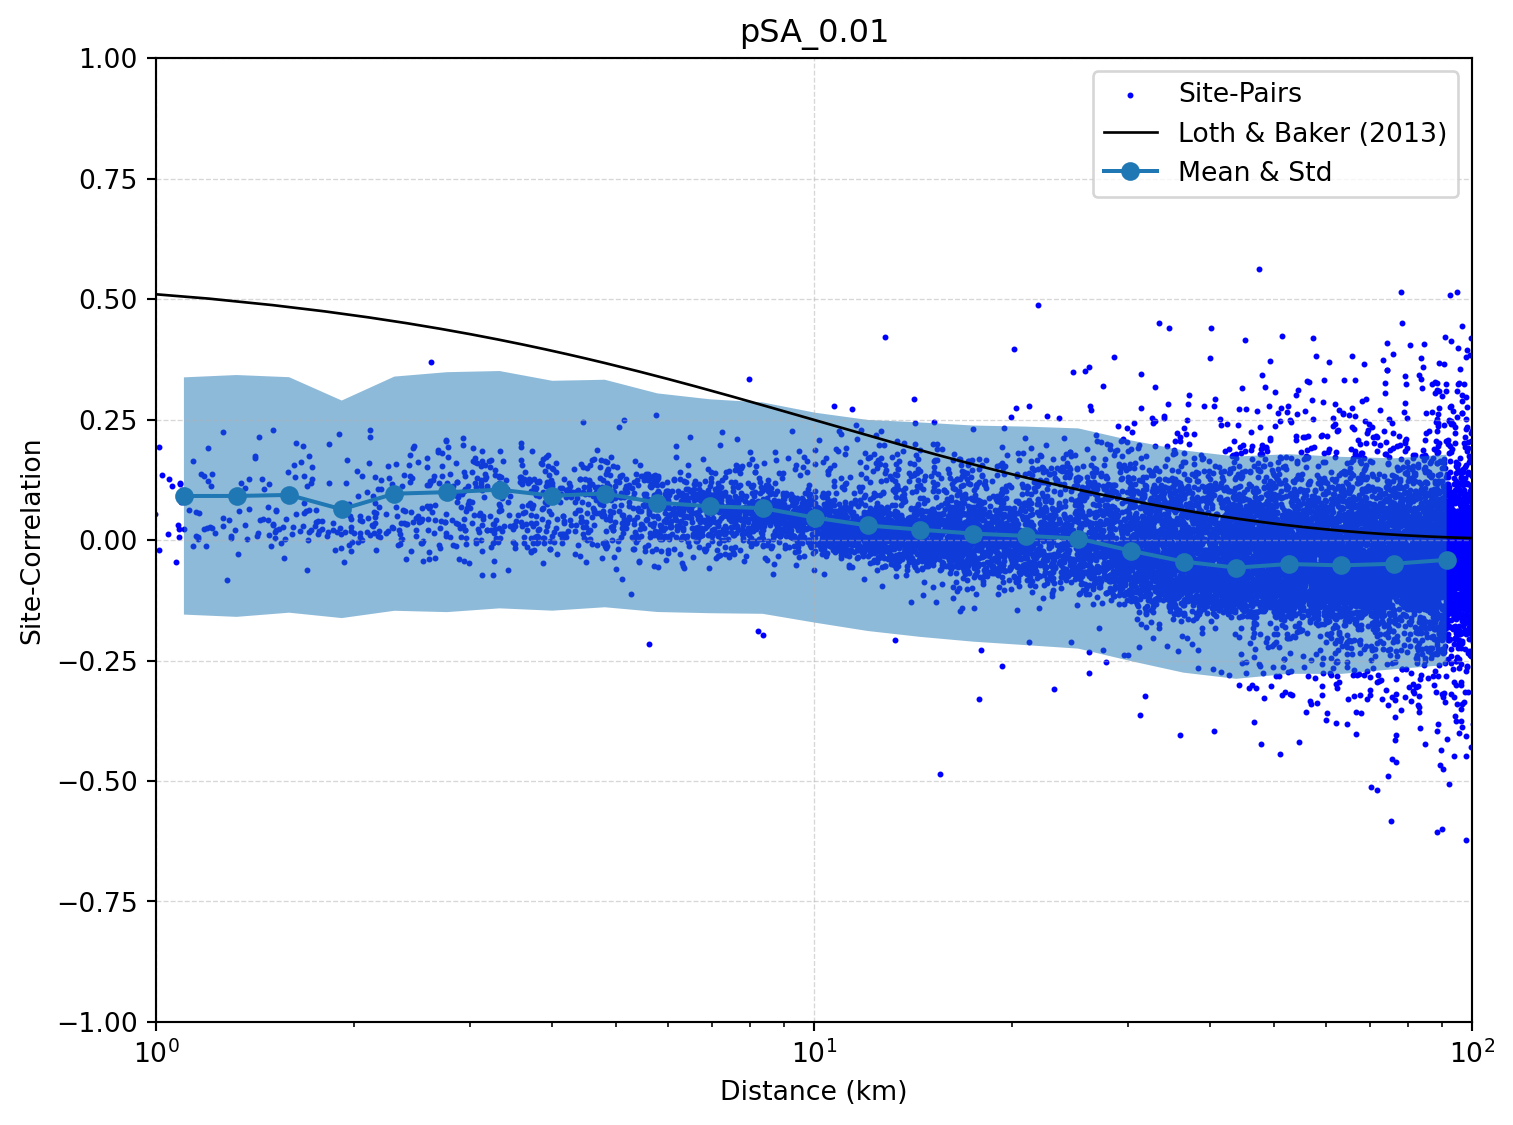

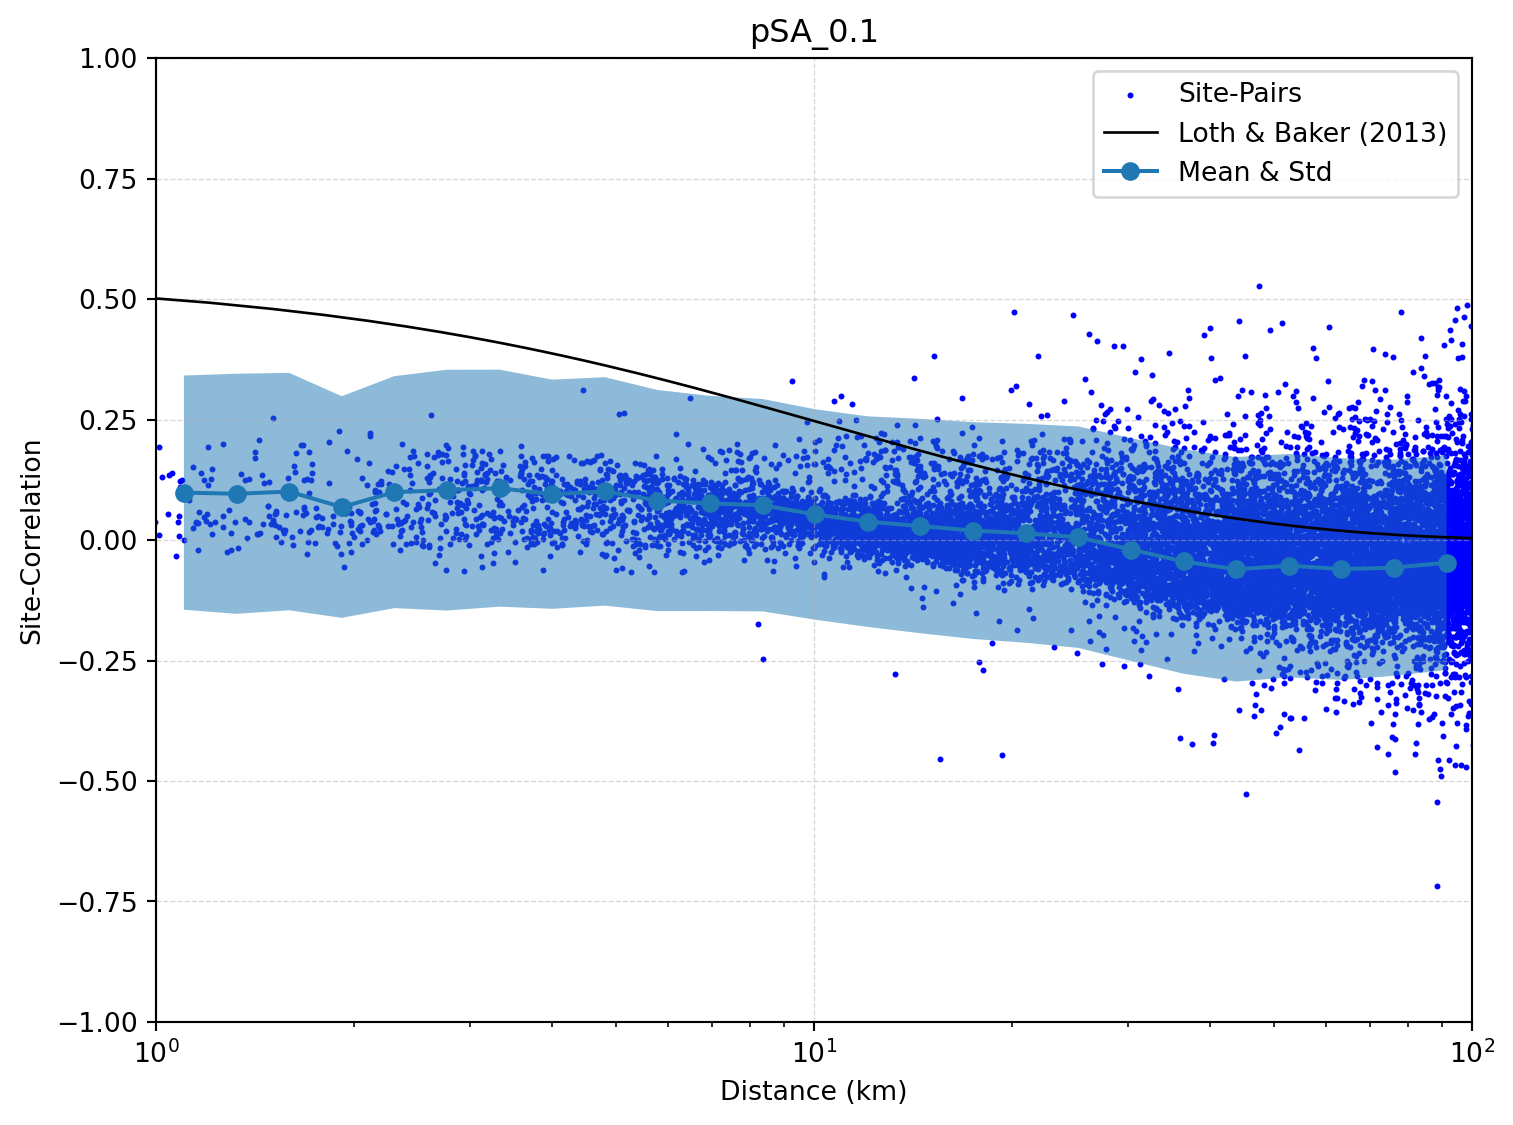

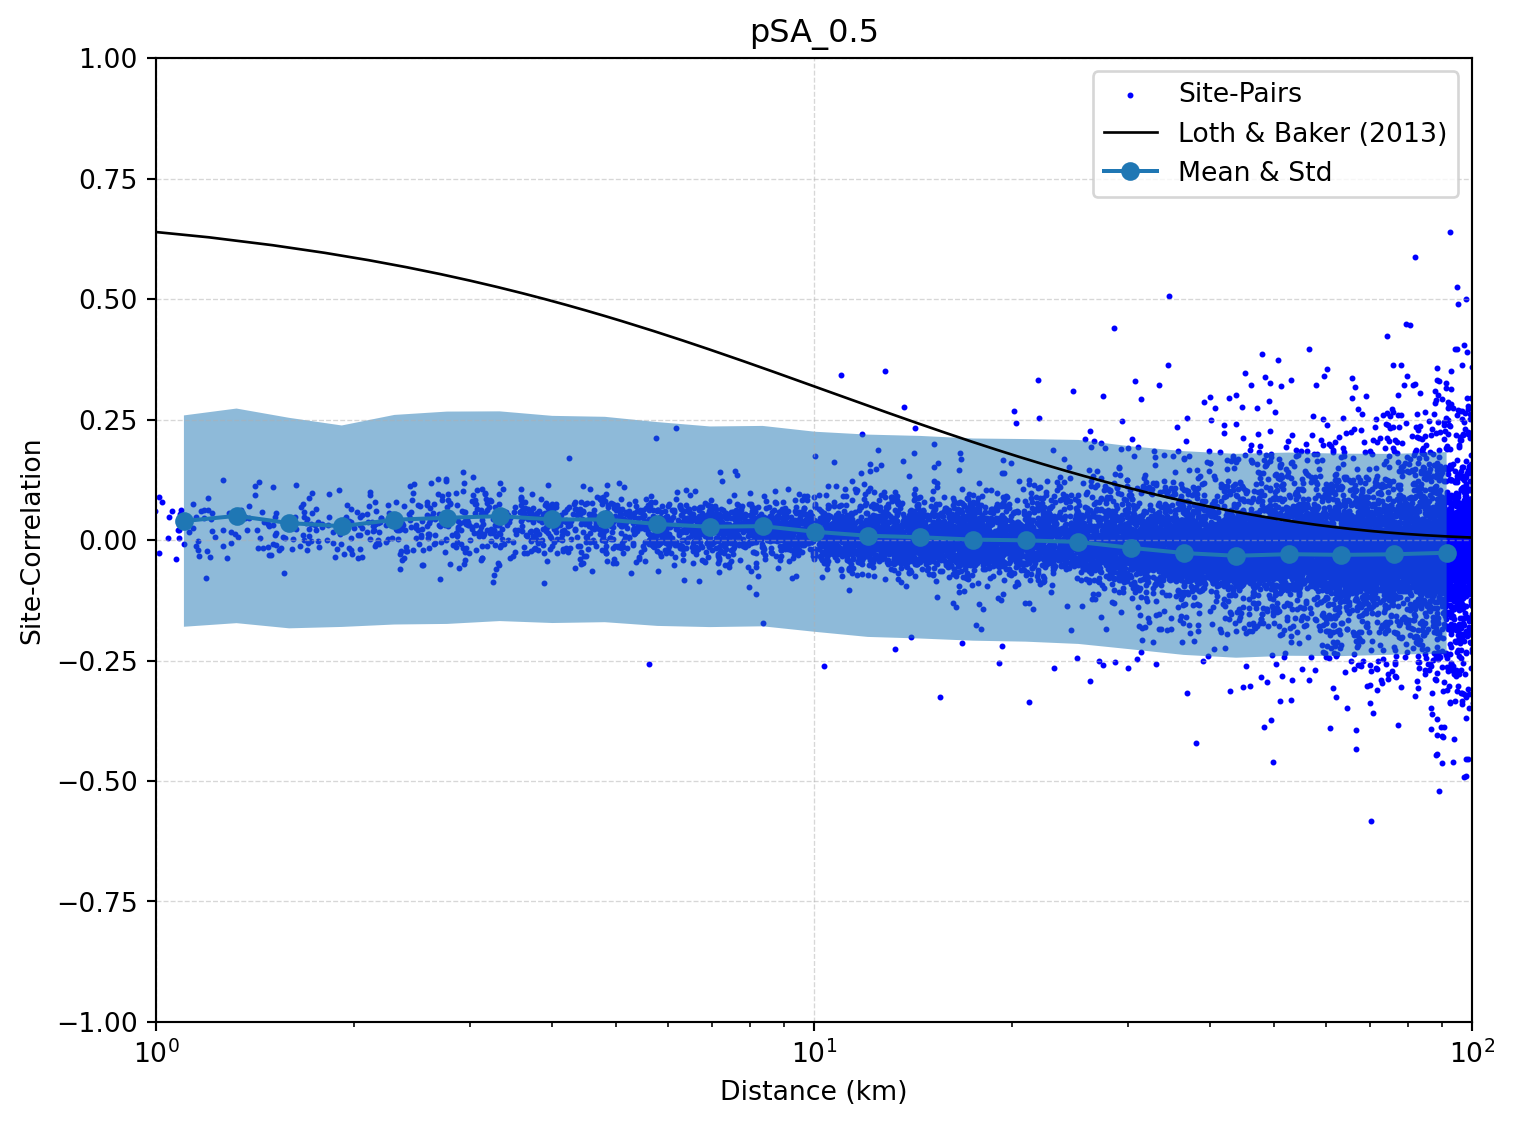

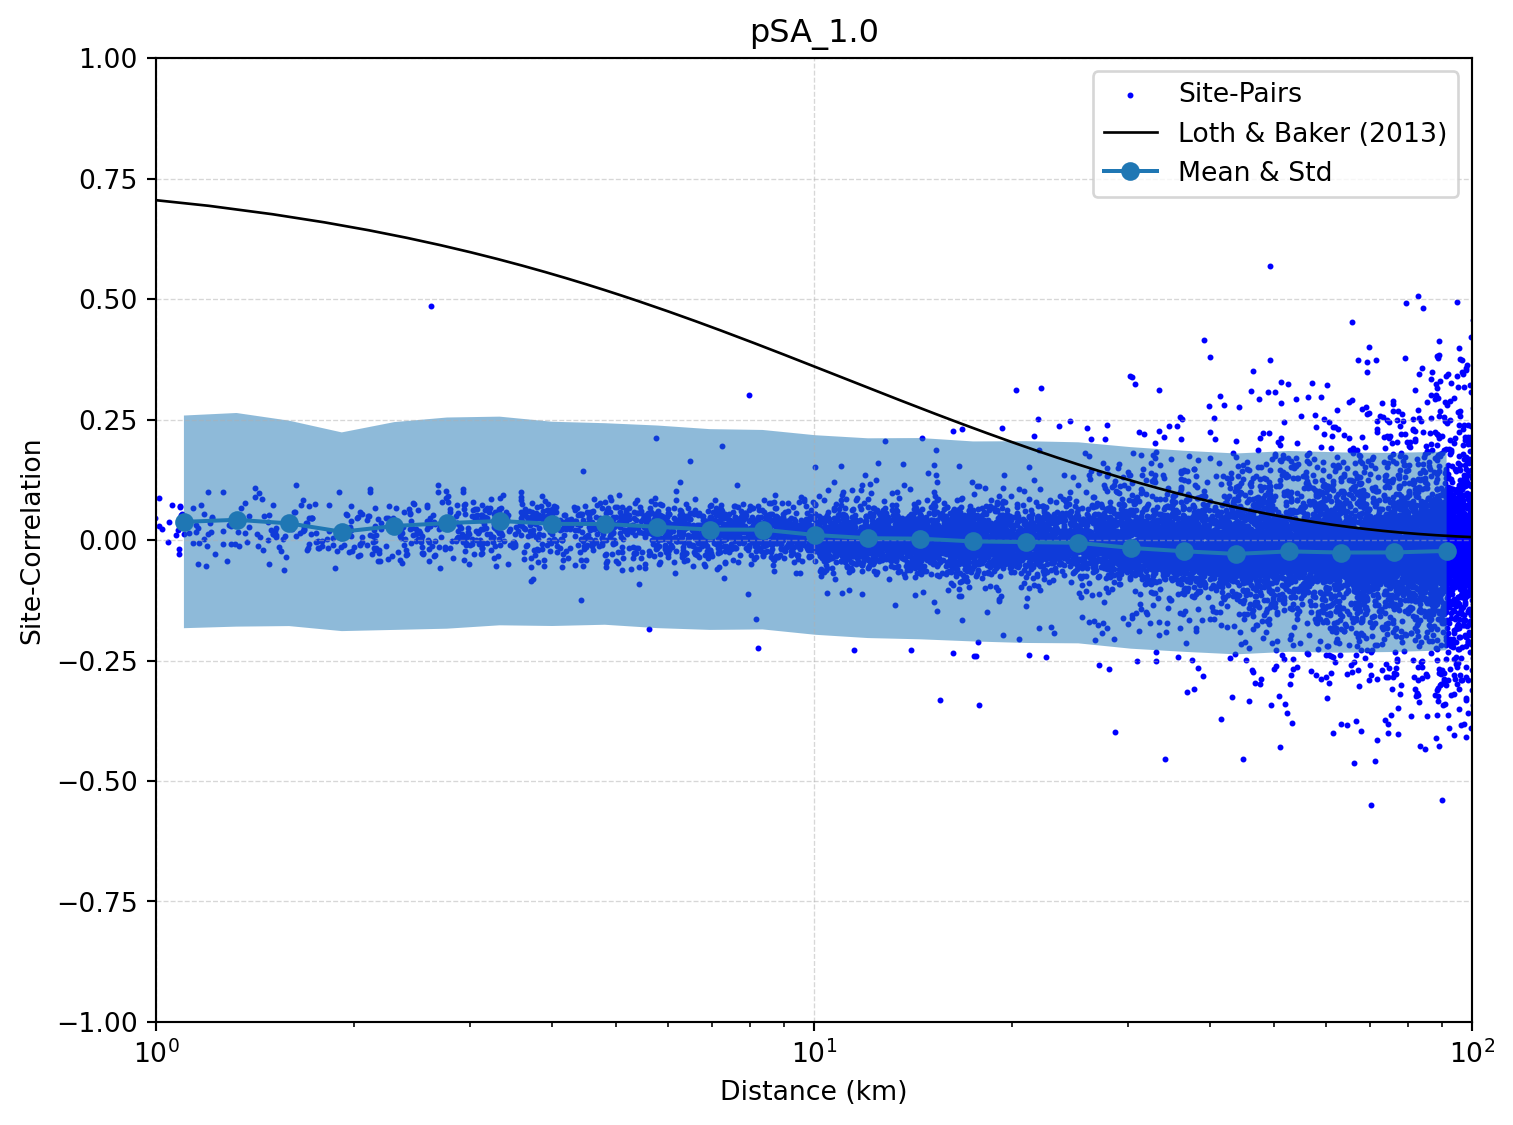

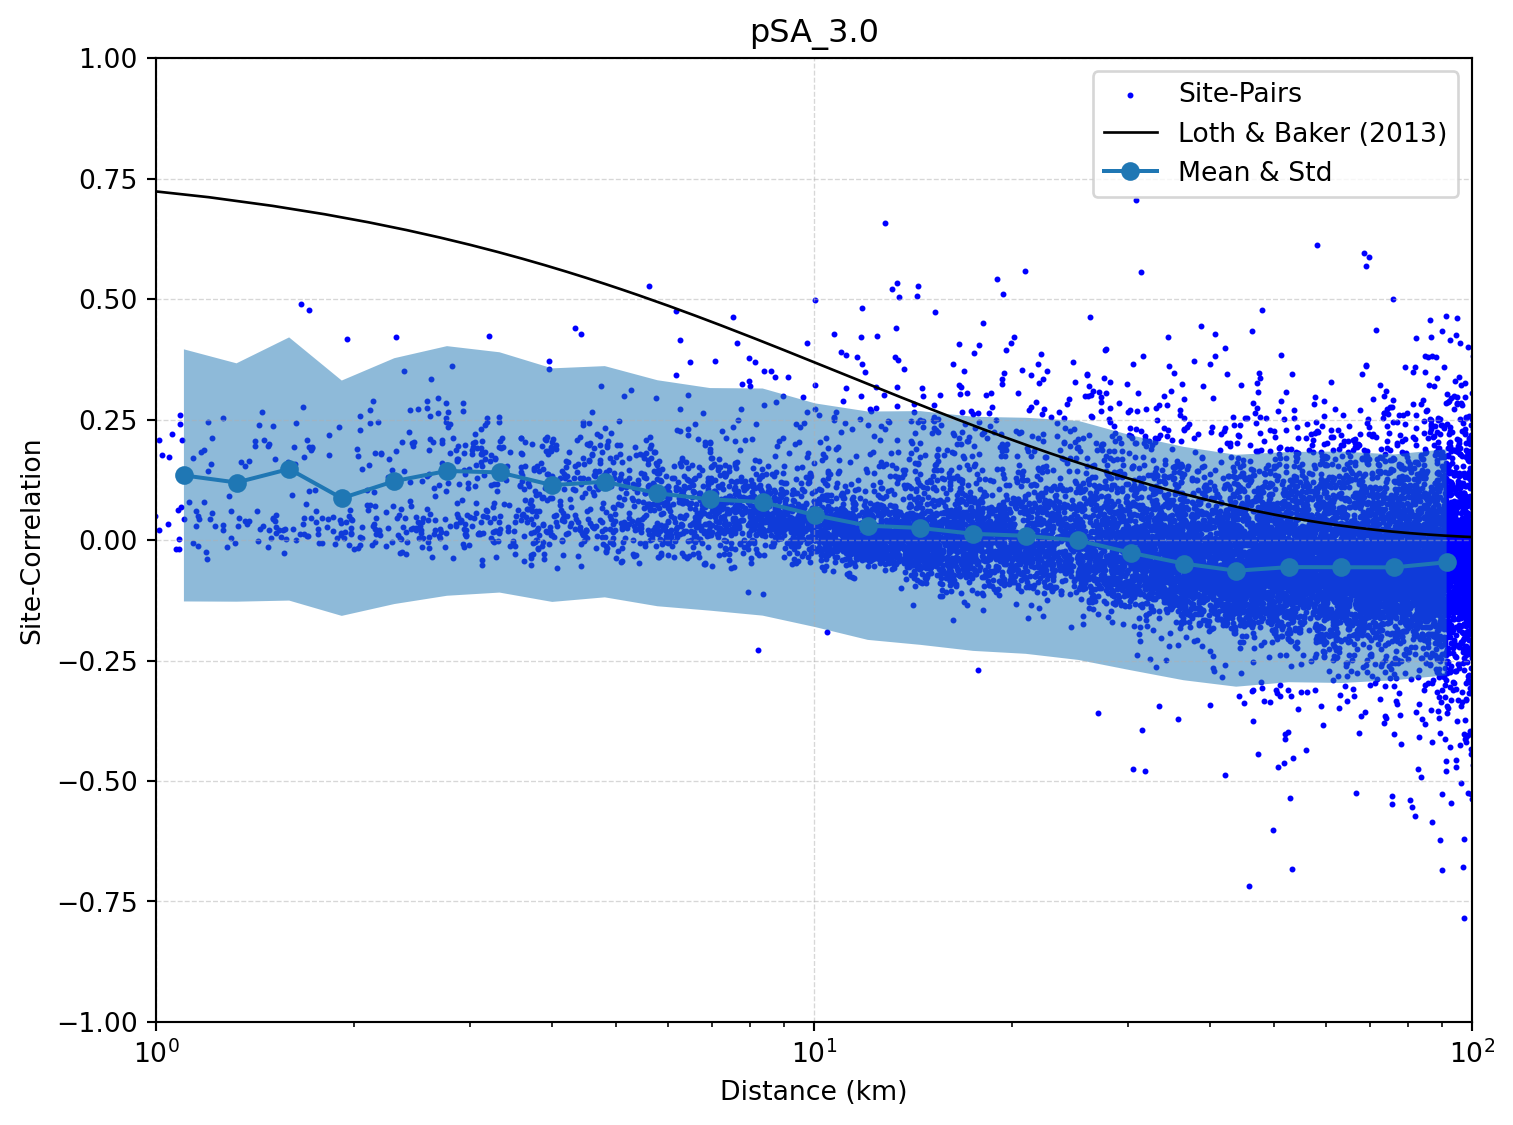

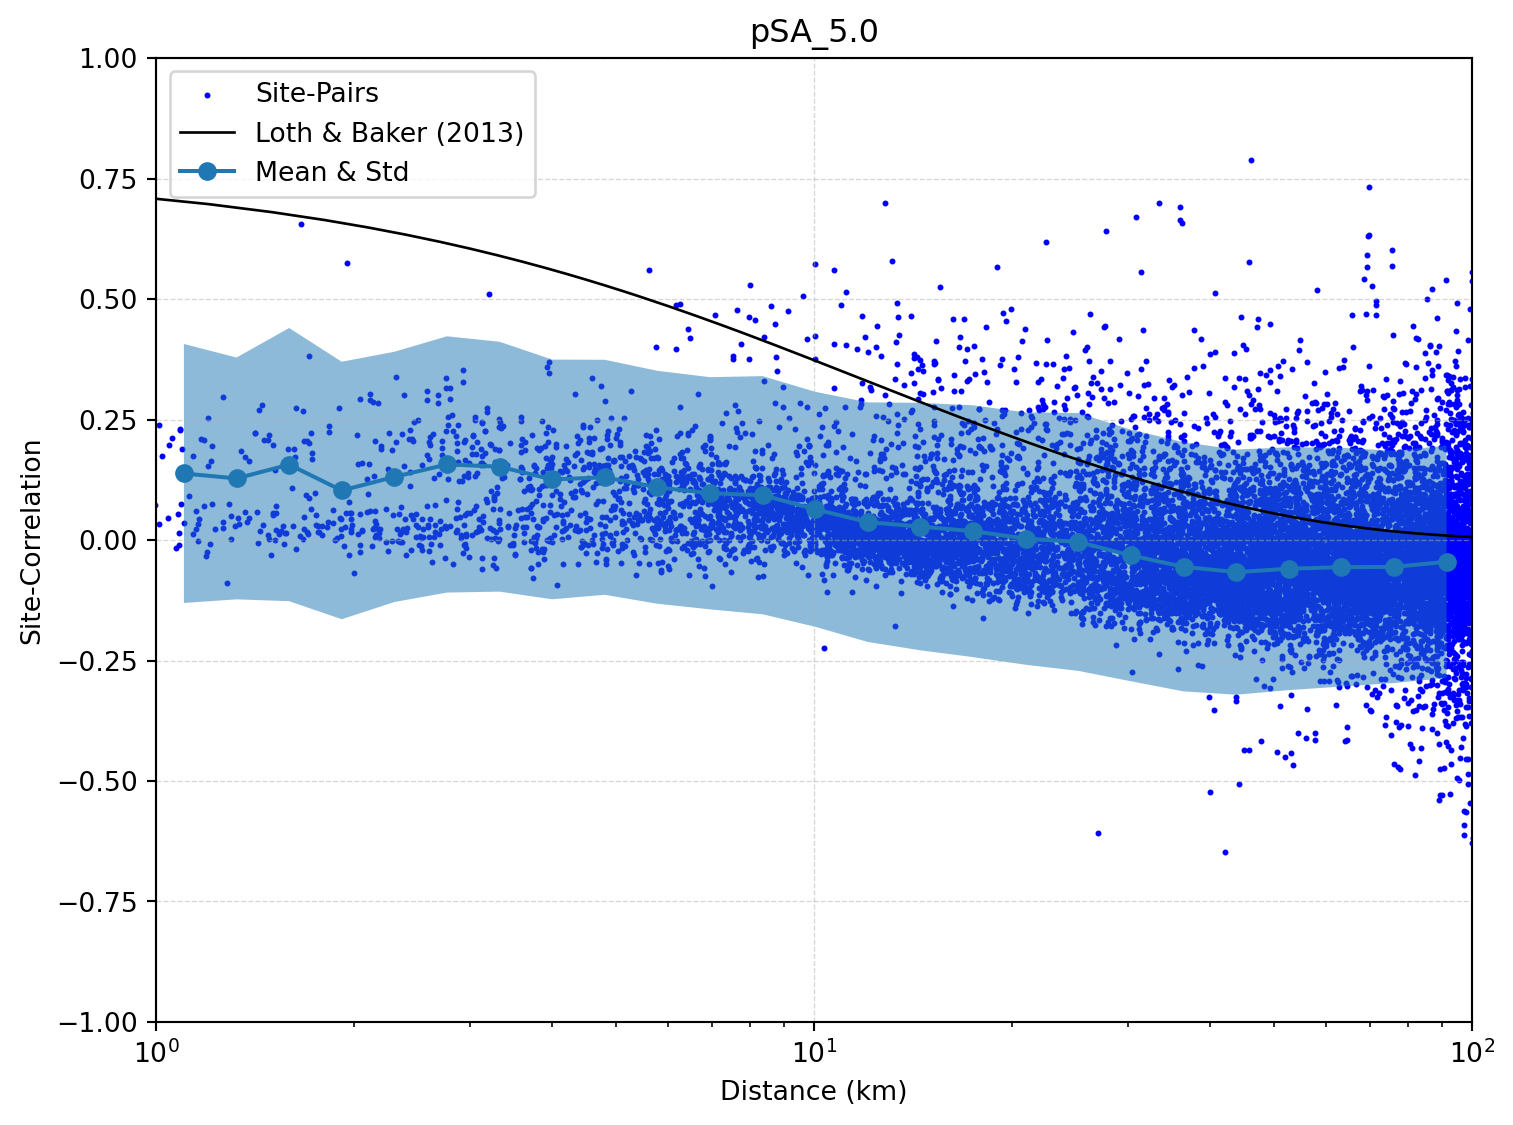

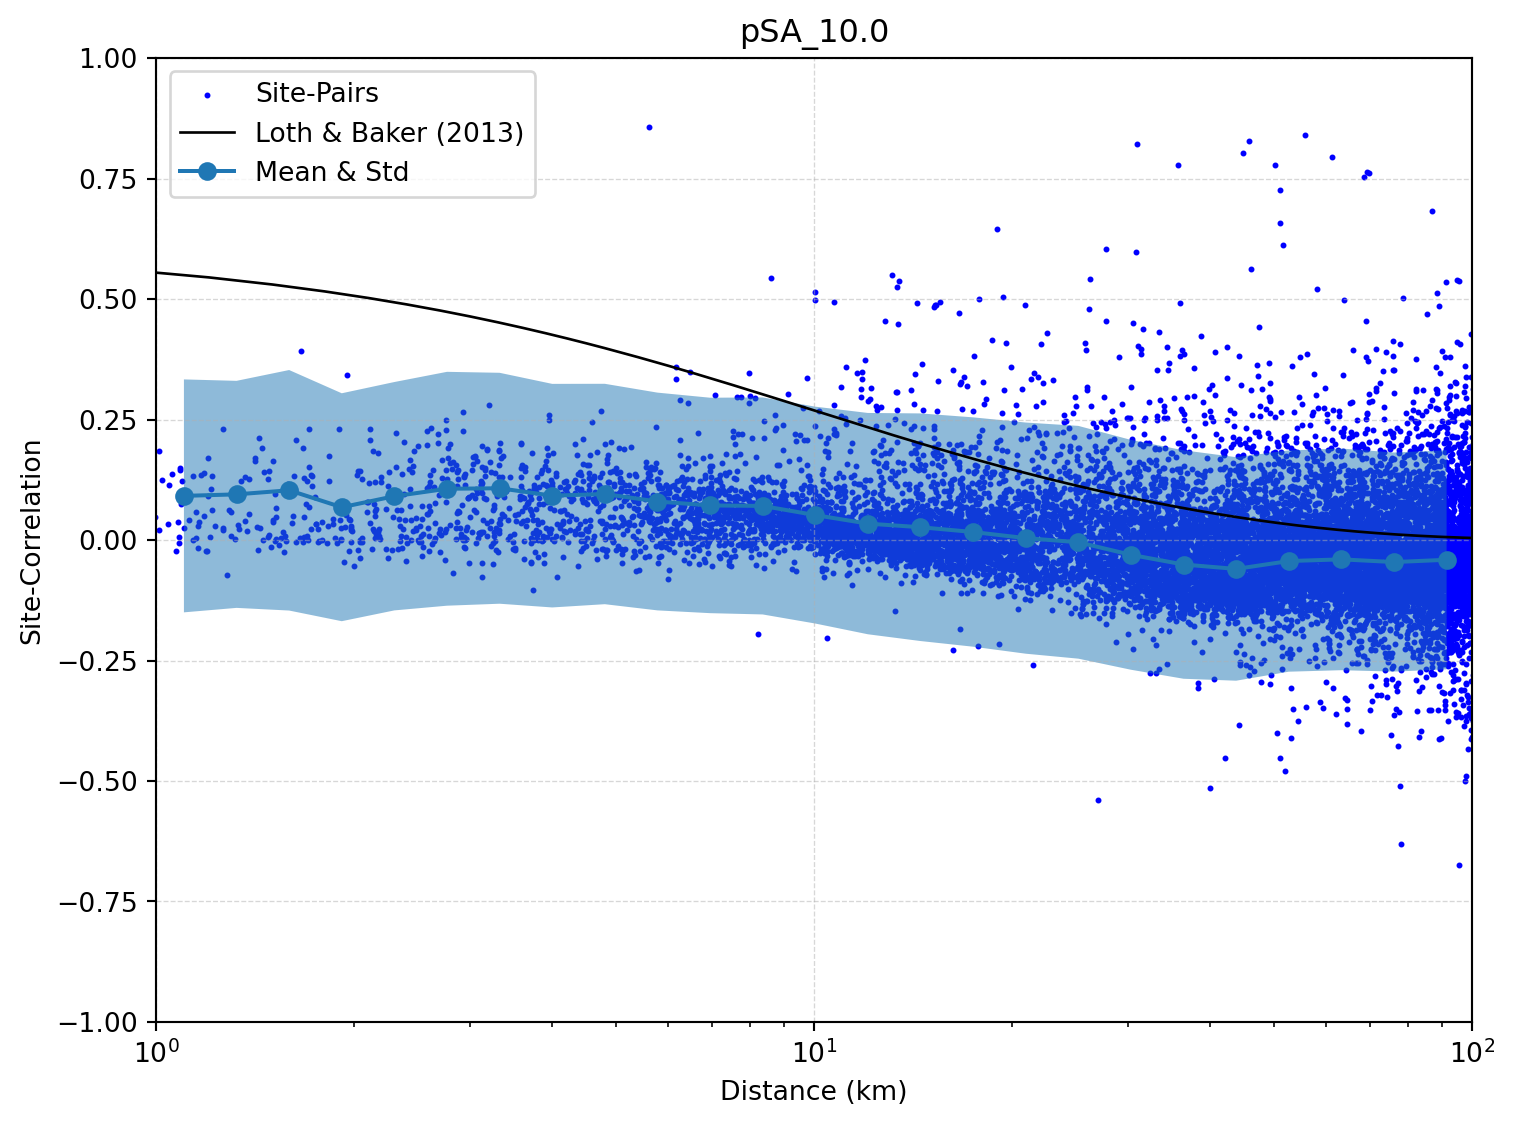

In [10]:
plt_ims = ["pSA_0.01", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_3.0", "pSA_5.0", "pSA_10.0"]
for plt_im in plt_ims:
	with warnings.catch_warnings(action="ignore", category=RuntimeWarning):
		cur_corr_df = pd.DataFrame(index=site_corrs_da.labels["site1"], columns=site_corrs_da.labels["site2"], data=np.nanmean(site_corrs_da.sel[:, :, :, plt_im], axis=2))
		
	mask = np.tril(dist_matrix.values).astype(bool) & ~cur_corr_df.isna().values
	ax = plot_corr(cur_corr_df, dist_matrix, mask, plt_im, title=plt_im)
	
	ax.plot(mean_corr.index, mean_corr[plt_im], marker="o", label="Mean & Std")
	ax.fill_between(mean_corr.index, mean_corr[plt_im] - std_corr[plt_im], mean_corr[plt_im] + std_corr[plt_im], alpha=0.5)
	ax.legend()
	

## Event-specific correlation
Spatial correlation of site-pairs for a single event (across all realisations)

#### Largest 5 events

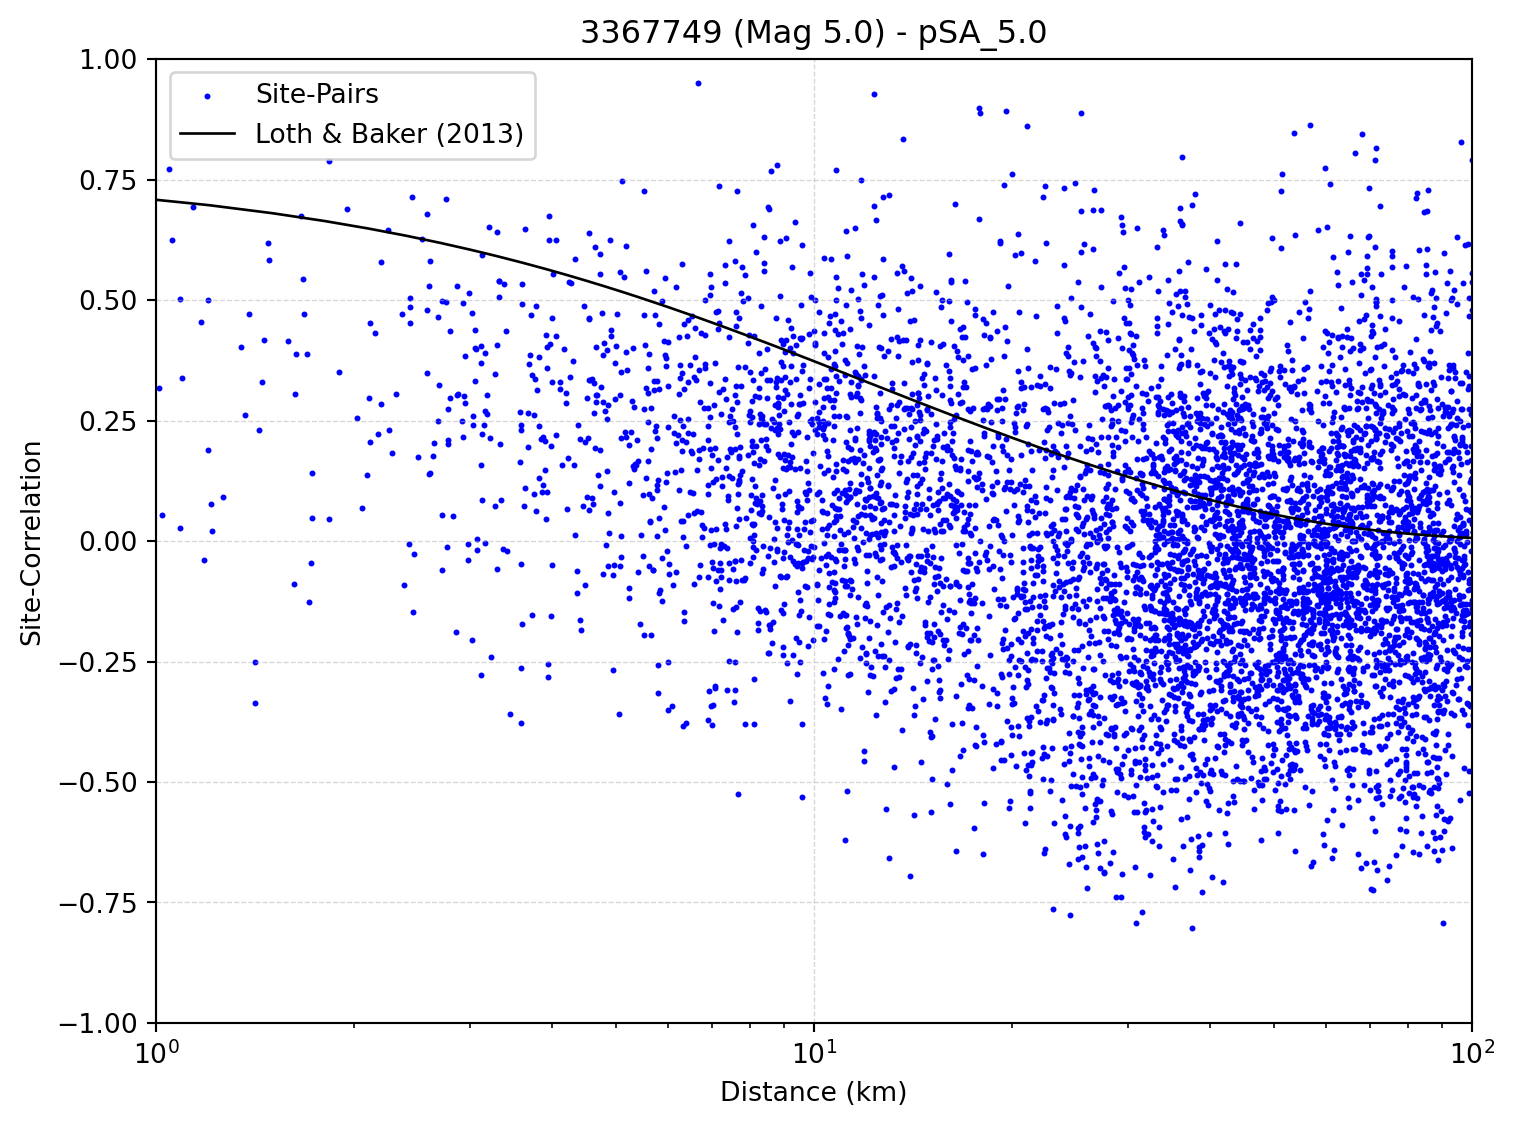

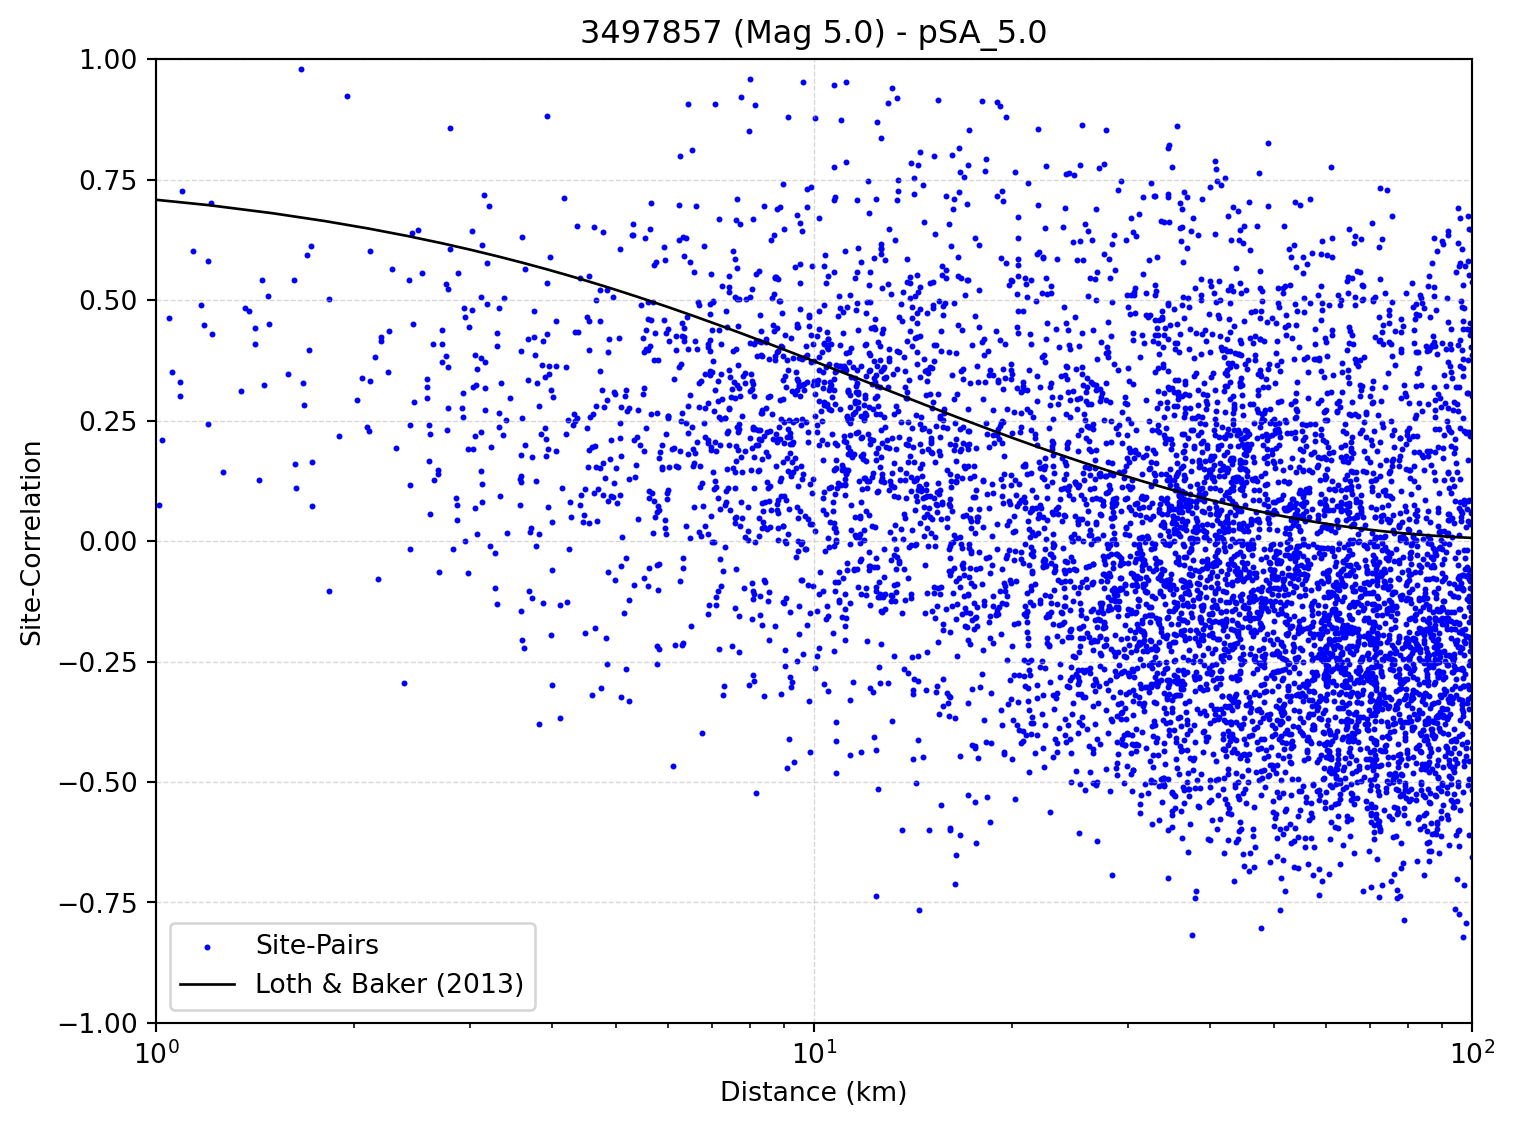

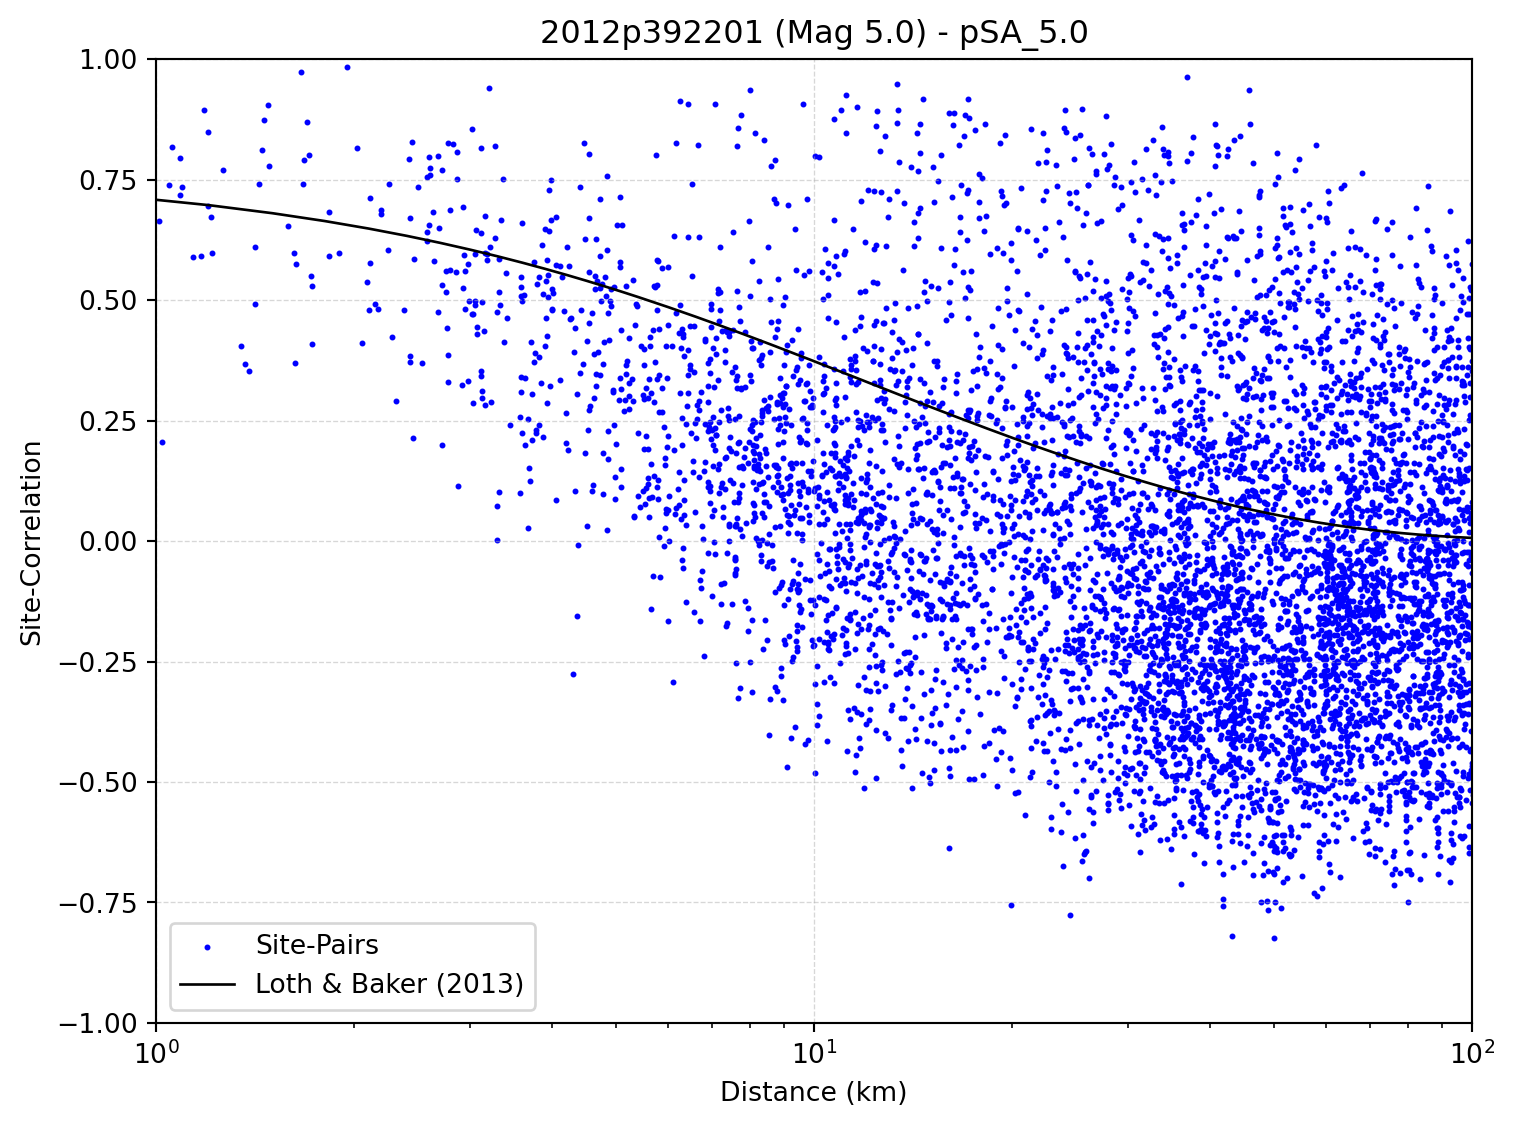

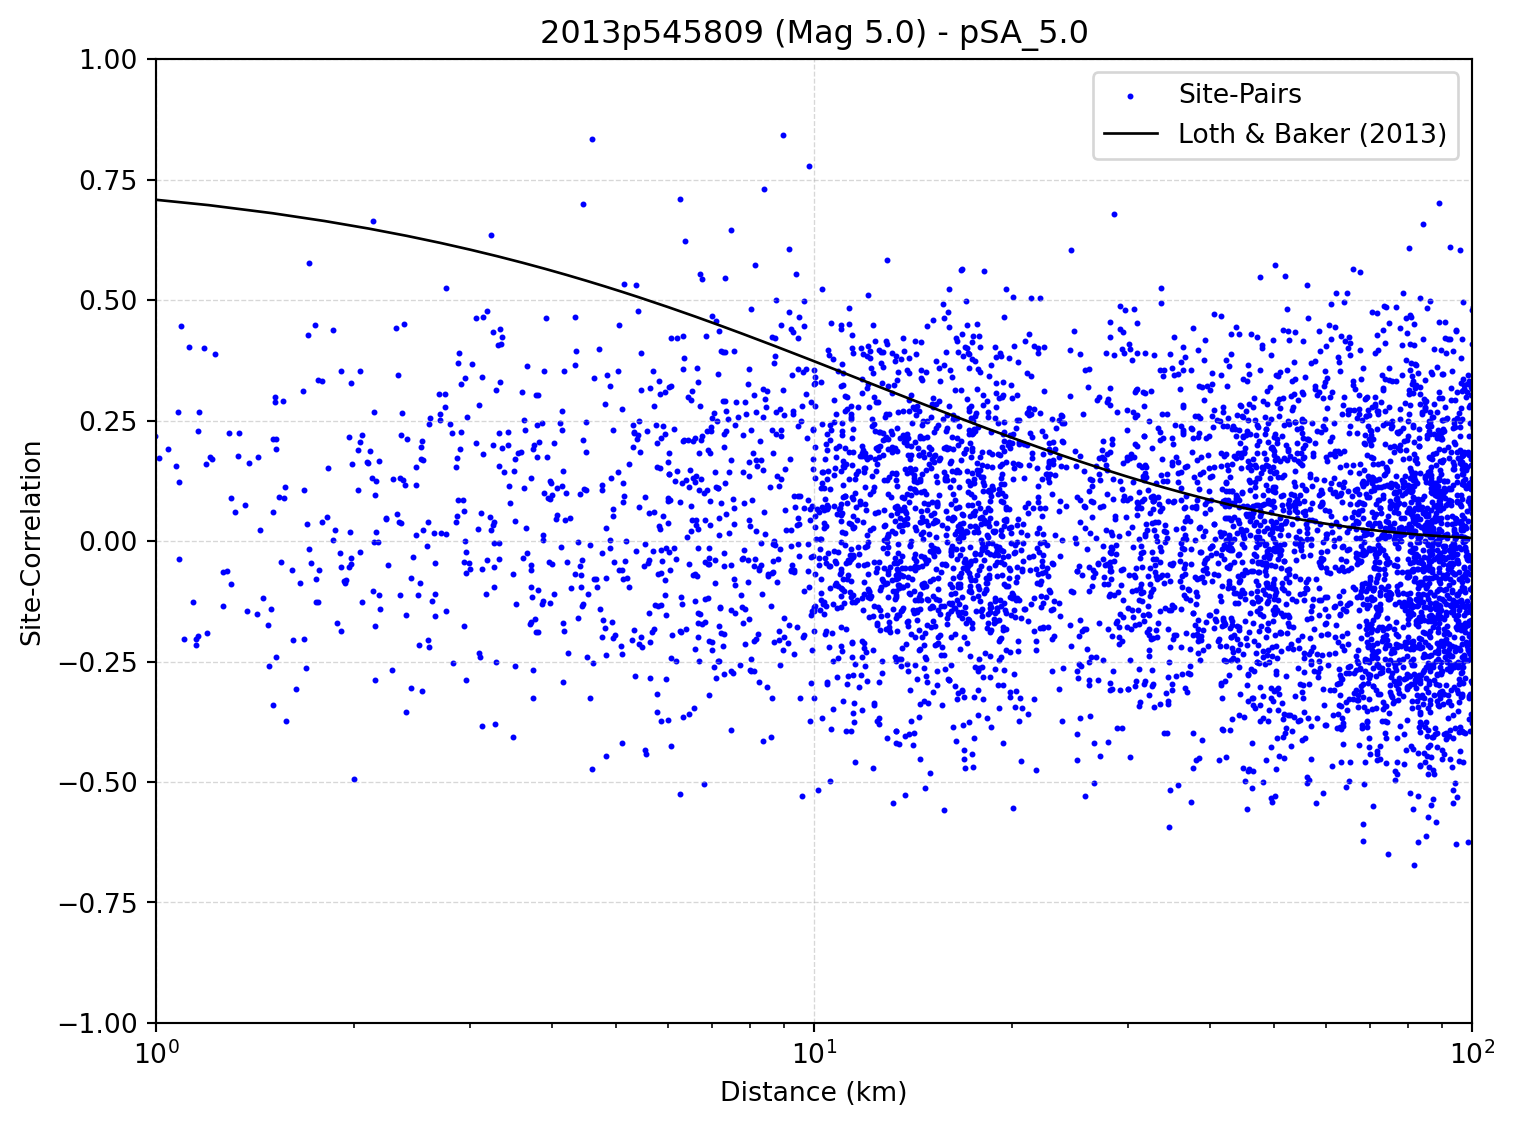

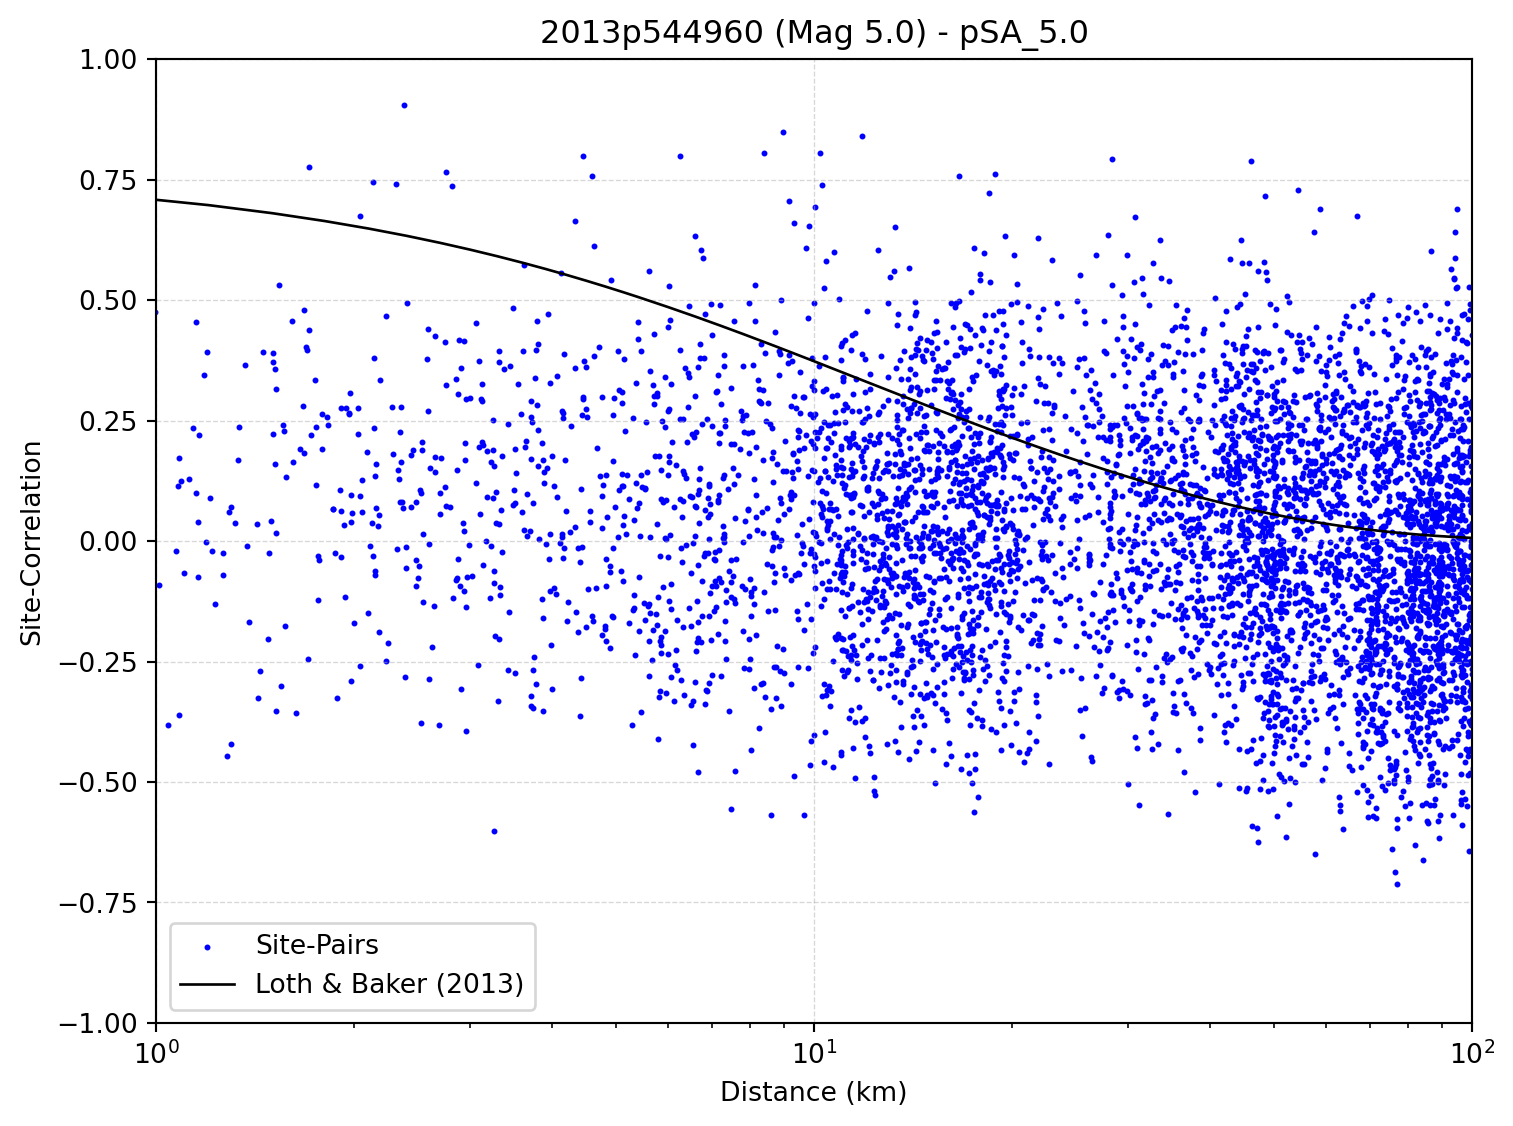

In [11]:
plt_im = "pSA_5.0"
plt_events = event_df.loc[events].sort_values("mag", ascending=False).index[:5]
for cur_event in plt_events:
	cur_corr = event_site_corrs[cur_event]
	plt_im_ix = np.flatnonzero(cur_corr.ims == plt_im)[0]
	cur_corr_df = pd.DataFrame(index=cur_corr.sites, columns=cur_corr.sites, data=cur_corr.corrs[:, :, plt_im_ix])
	cur_dist_matrix = dist_matrix.loc[cur_corr.sites, cur_corr.sites]
	mask = np.tril(cur_dist_matrix.values).astype(bool) & ~cur_corr_df.isna().values
	ax = plot_corr(cur_corr_df, cur_dist_matrix, mask, plt_im, title=f"{cur_event} (Mag {event_df.loc[cur_event].mag}) - {plt_im}")
	ax.legend()

#### Smallest 5 events
     

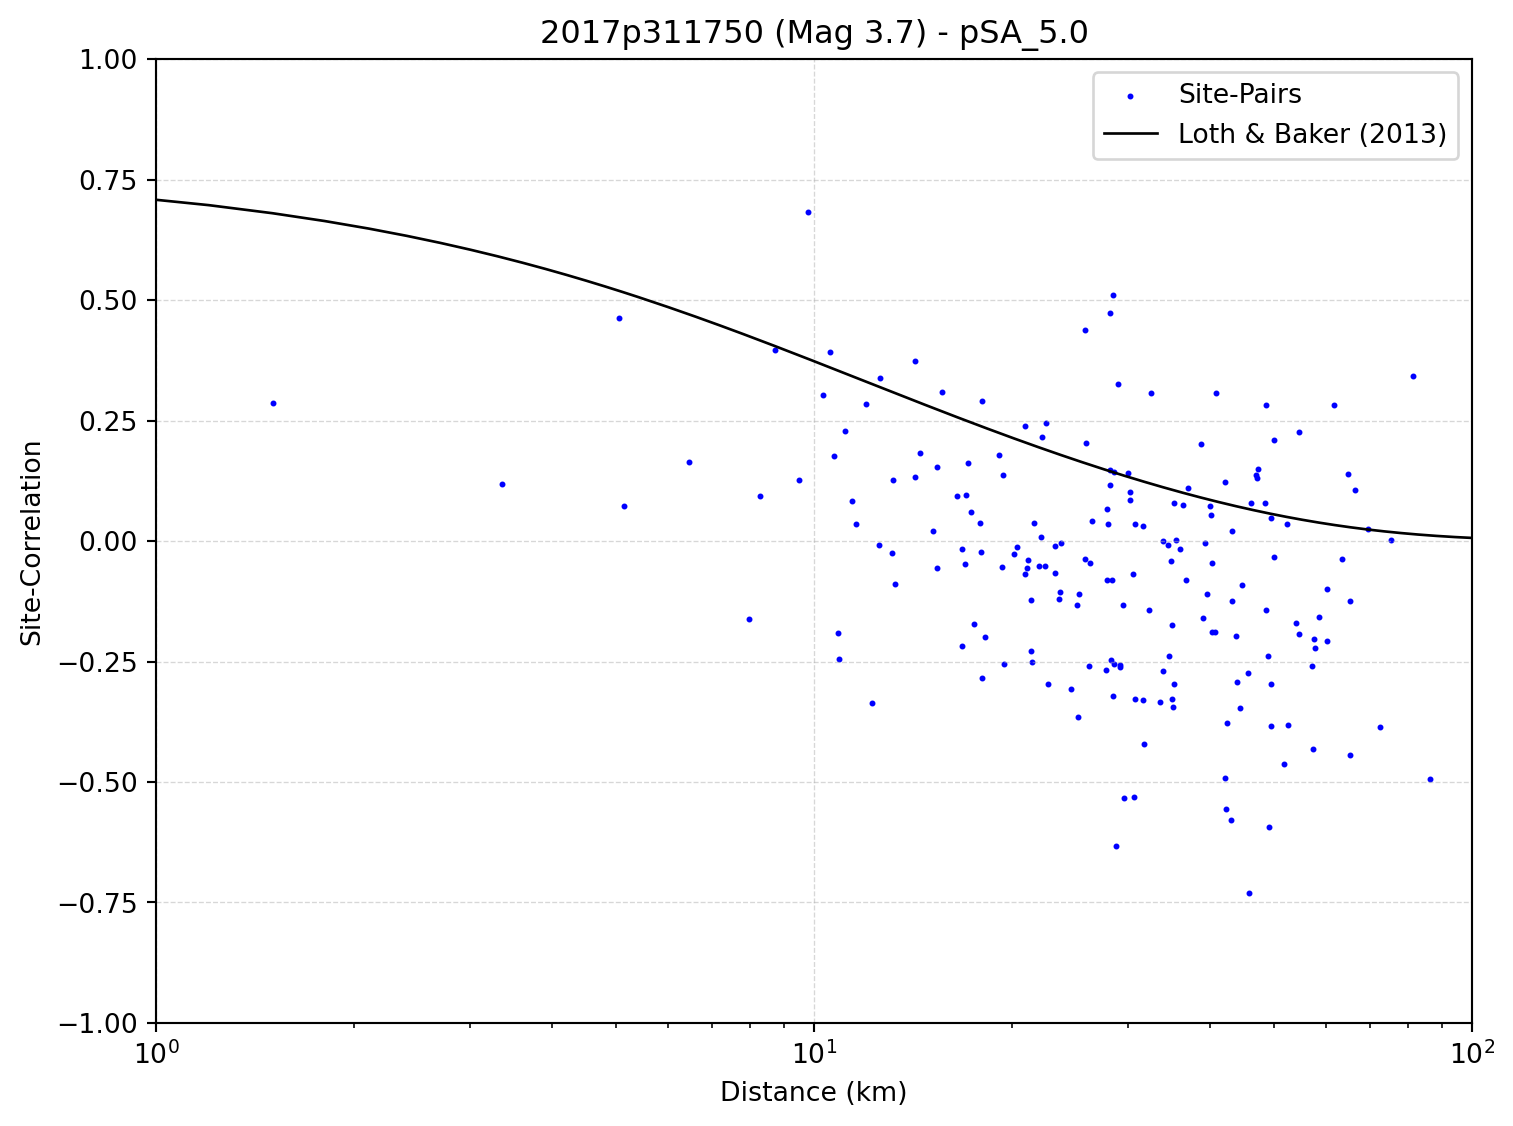

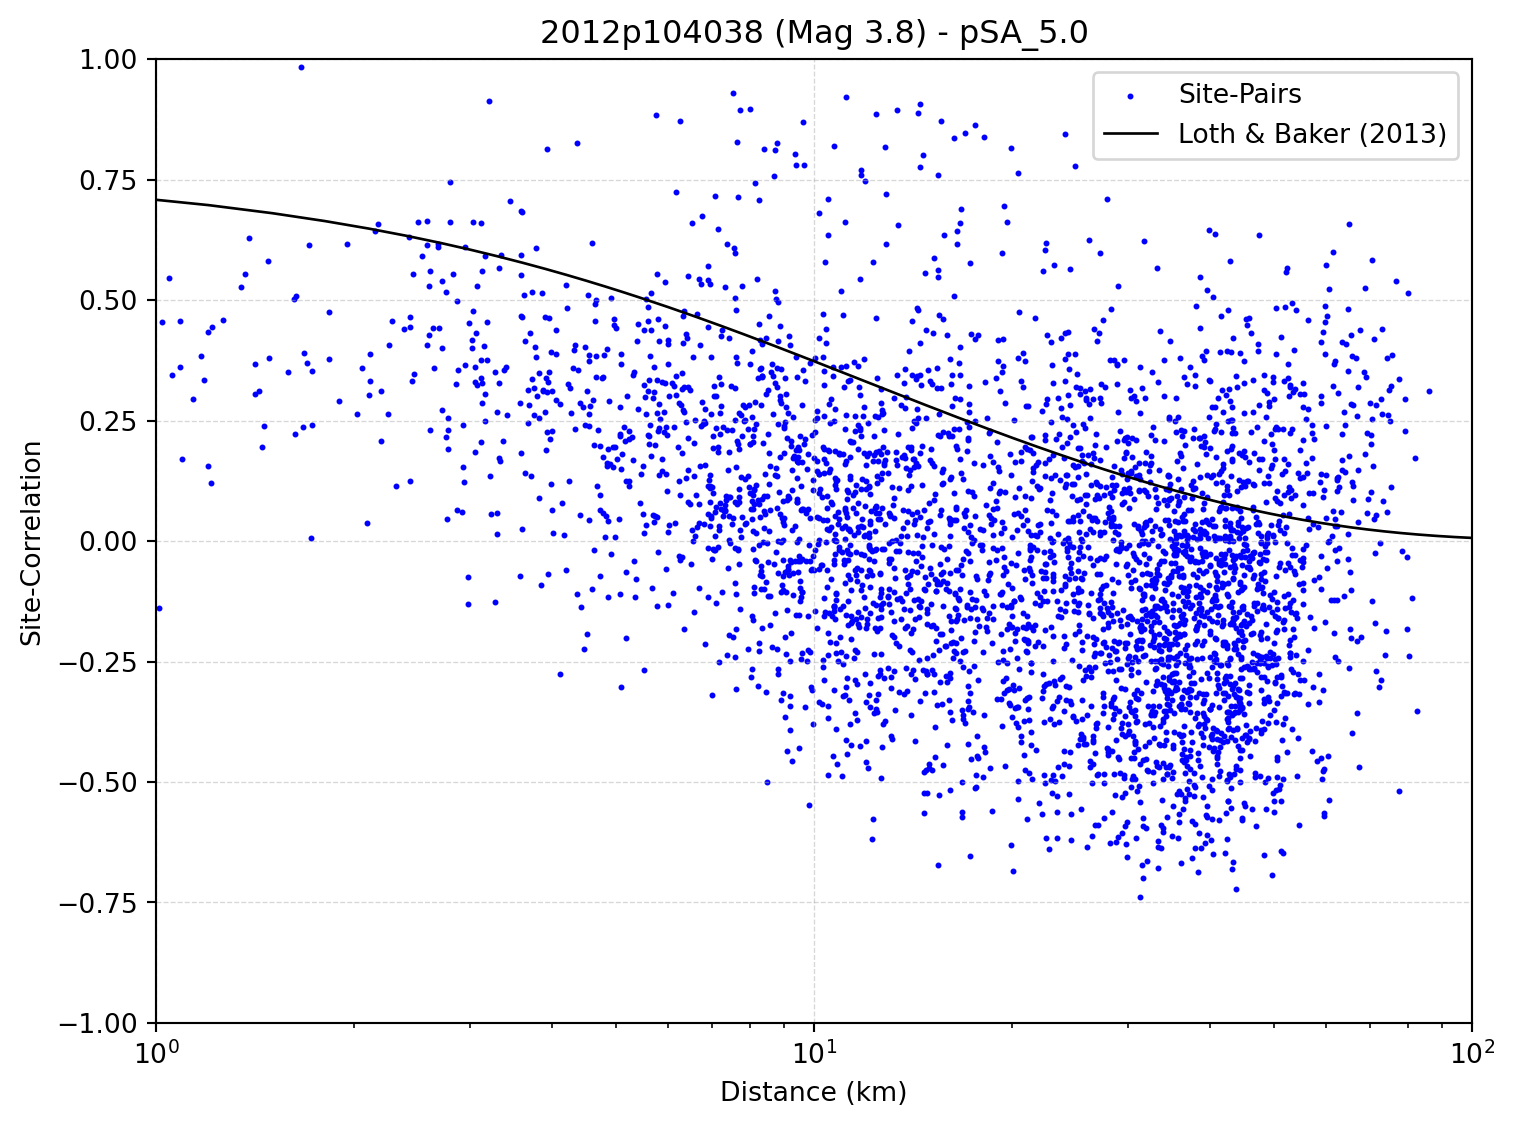

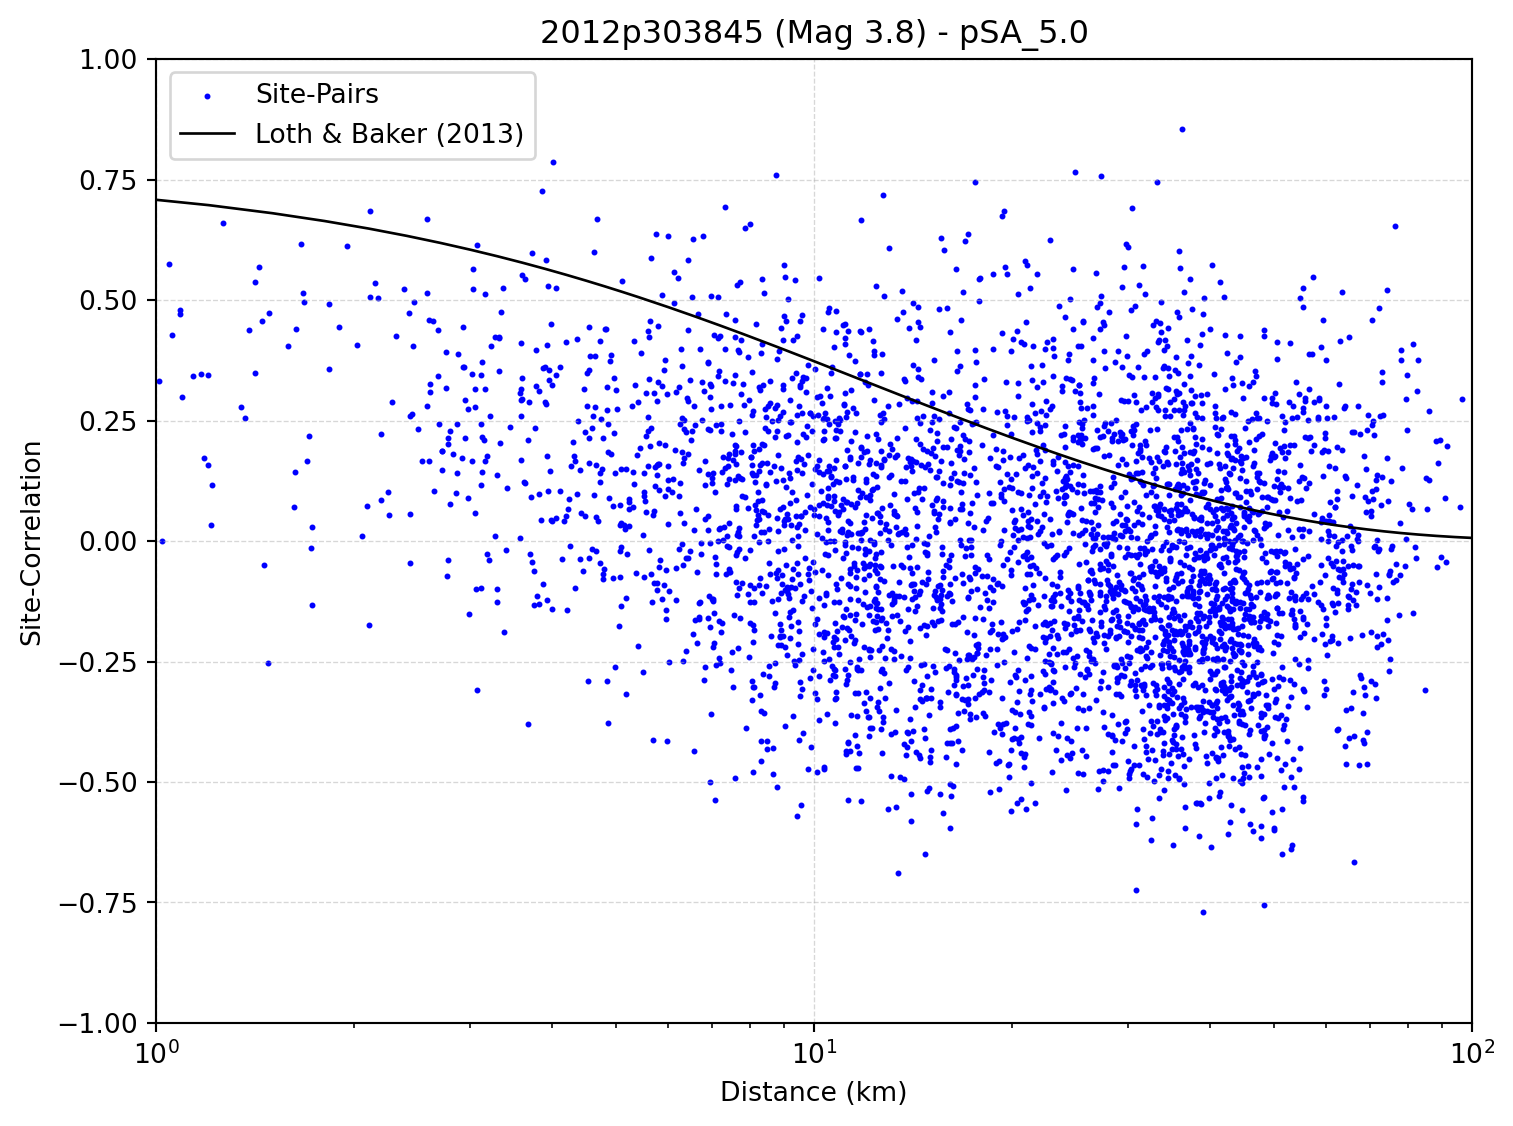

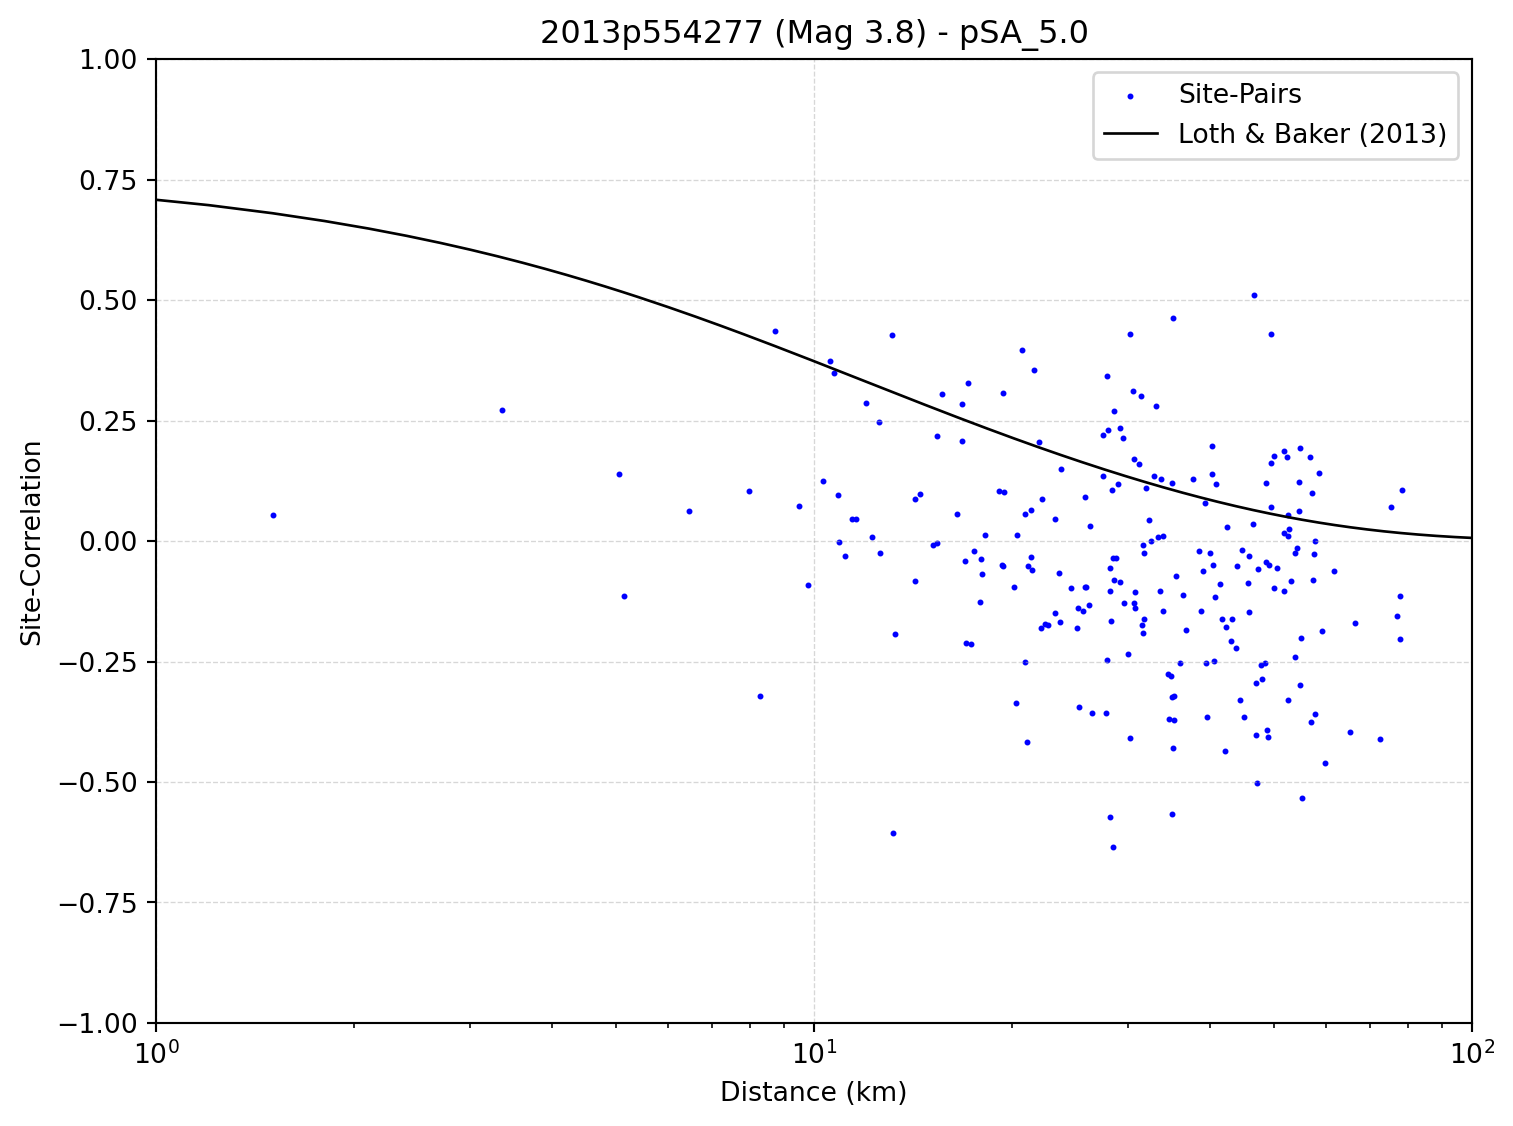

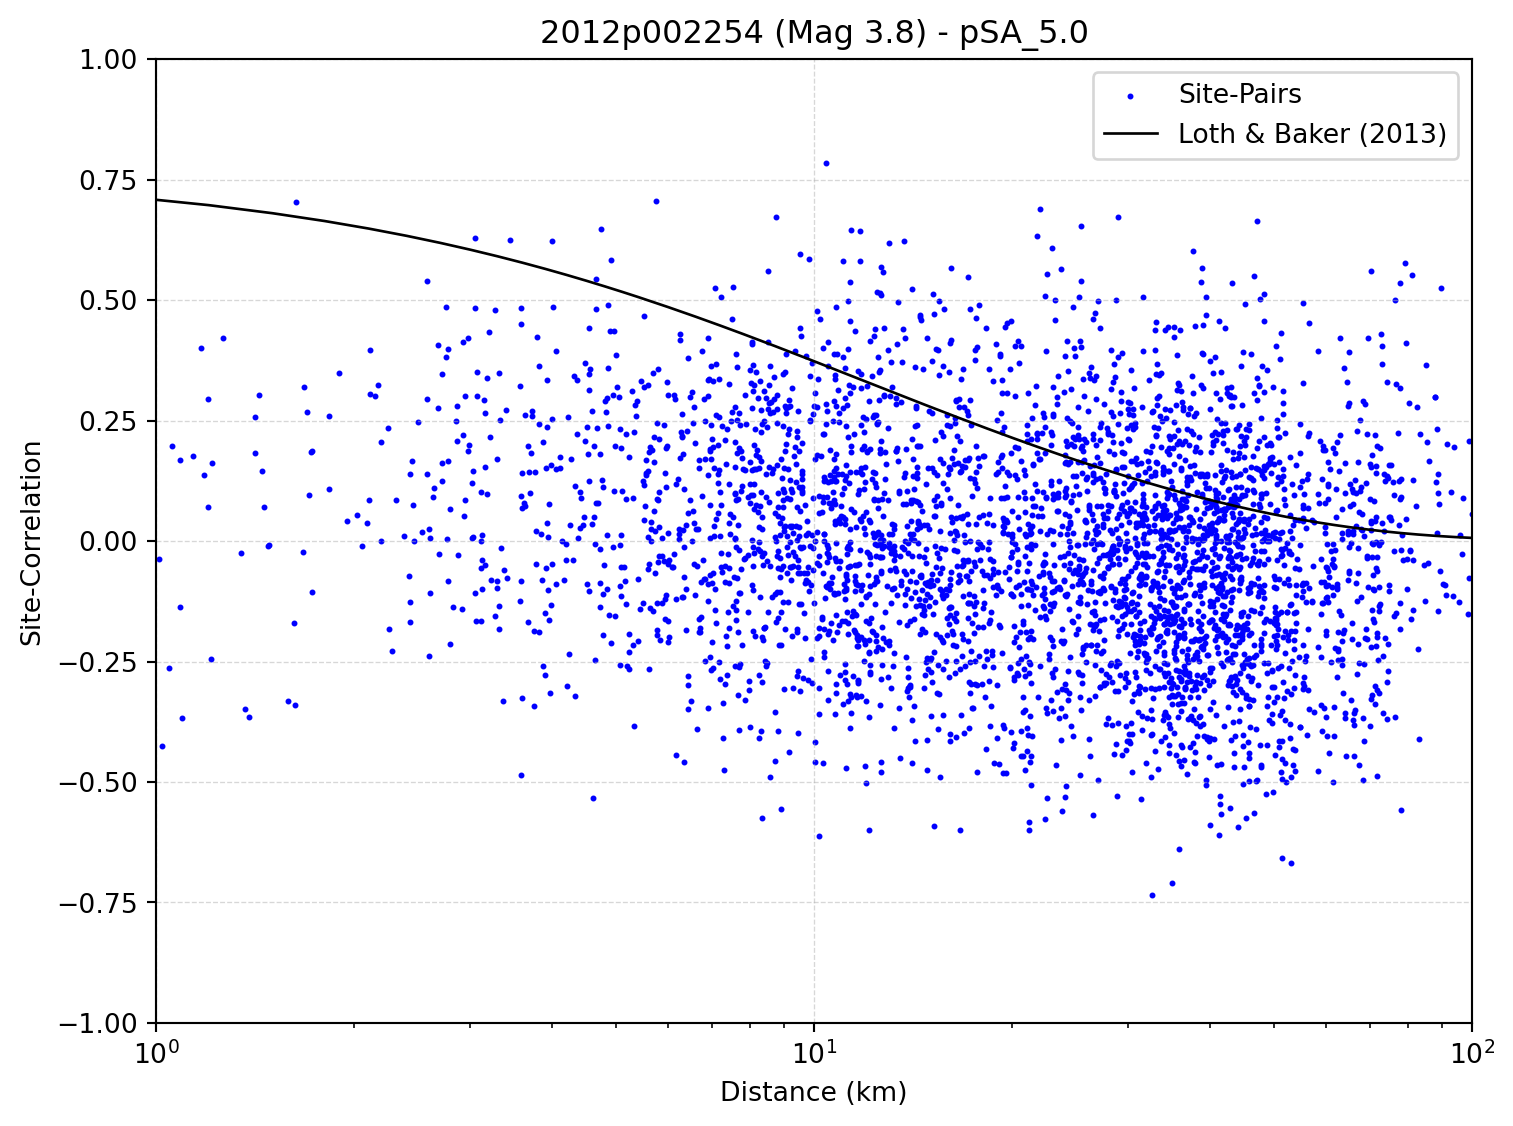

In [12]:
plt_im = "pSA_5.0"
plt_events = event_df.loc[events].sort_values("mag", ascending=True).index[:5]
for cur_event in plt_events:
	cur_corr = event_site_corrs[cur_event]
	plt_im_ix = np.flatnonzero(cur_corr.ims == plt_im)[0]
	cur_corr_df = pd.DataFrame(index=cur_corr.sites, columns=cur_corr.sites, data=cur_corr.corrs[:, :, plt_im_ix])
	cur_dist_matrix = dist_matrix.loc[cur_corr.sites, cur_corr.sites]
	mask = np.tril(cur_dist_matrix.values).astype(bool) & ~cur_corr_df.isna().values
	ax = plot_corr(cur_corr_df, cur_dist_matrix, mask, plt_im, title=f"{cur_event} (Mag {event_df.loc[cur_event].mag}) - {plt_im}")
	ax.legend()